In [268]:
import sys
sys.path.insert(0, "/home/syedkazim/sciebo - Kazim, Syed Muhammad (u491036@uni-siegen.de)@uni-siegen.sciebo.de/Lab/Projects/2024_Phase_Camera_FM_Design/coded_wfs_sim")

from coded_wfs_sim import geometry
from coded_wfs_sim import propagator
from coded_wfs_sim import visualization
from coded_wfs_sim import utils

import numpy as np
from tifffile import tifffile
from matplotlib import pyplot as plt
import cv2

from scipy.ndimage import gaussian_filter
from scipy.signal import correlate2d, convolve2d, tukey
from scipy.interpolate import RegularGridInterpolator

# Propagation effects on Speckle size

**Moving completely to thin lens modeling**

*Finding: Propagation does not effect speckle sizes*

* ~~Ensuring proper sampling, wavefield size, and boundary conditions~~
* *Simulate and save phase mask with proper sizes*
    * Try different densities of structures
    * ~~Compare outputs from different samplings~~
* Ensure proper simulation w.r.t. medium RIs
* ~~Compare BPM vs Thin sample modeling~~
    * *Make videos for propagation distances*
* Problem specification: FOV and same sampling, but spatial resolution/ spatial frequency limited by distance and speckle size?
    * *Speckle size increases with distance?*
* Averaging opoerator with stride to map output onto sensor pixels
* Finding minimum sampling frequency: Confirm when sampling frequency starts to effect output

((2000, 2000), dtype('float64'))

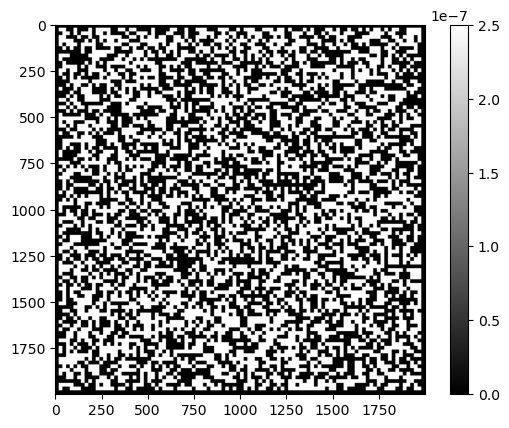

In [2]:
# create phase mask: 
# 2d matrix height map for phase delay
# 2d matrix for different RI?

# Grid and propagation parameters setup
wl = 640e-9
n_0 = 1.

dx = 500e-9 # dx == dy
nx = 2000 # nx == ny
side_length = 10e-6

tile_size = int(side_length/dx)

h_map = geometry.initialize_hmap_uniform_sampling([nx, nx], tile_size, 250e-9, prob=0.5)

plt.imshow(h_map, cmap='gray')
plt.colorbar()

h_map.shape, h_map.dtype

In [3]:
print(np.unique(h_map))

## given h_map, find delay of entire plane corresponding to the largest height
## max h_map = t
## delay at largest height = t*RI(x,y)
## delay where height = 0, t*1
## remaining regions: h(x,y)*RI(x,y) + (1-h(x,y)*1)

t = h_map.max()
RI = np.ones_like(h_map)*1.46
opd = h_map*RI + (t-h_map)*n_0

[0.0e+00 2.5e-07]


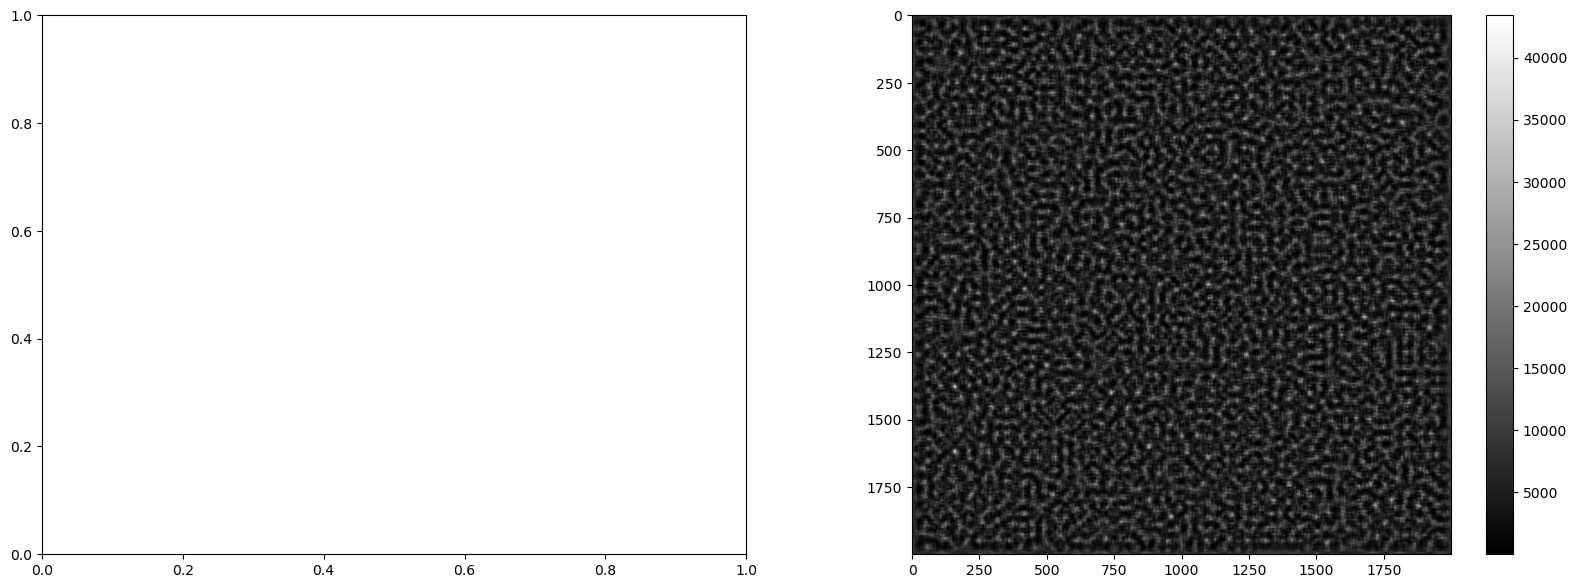

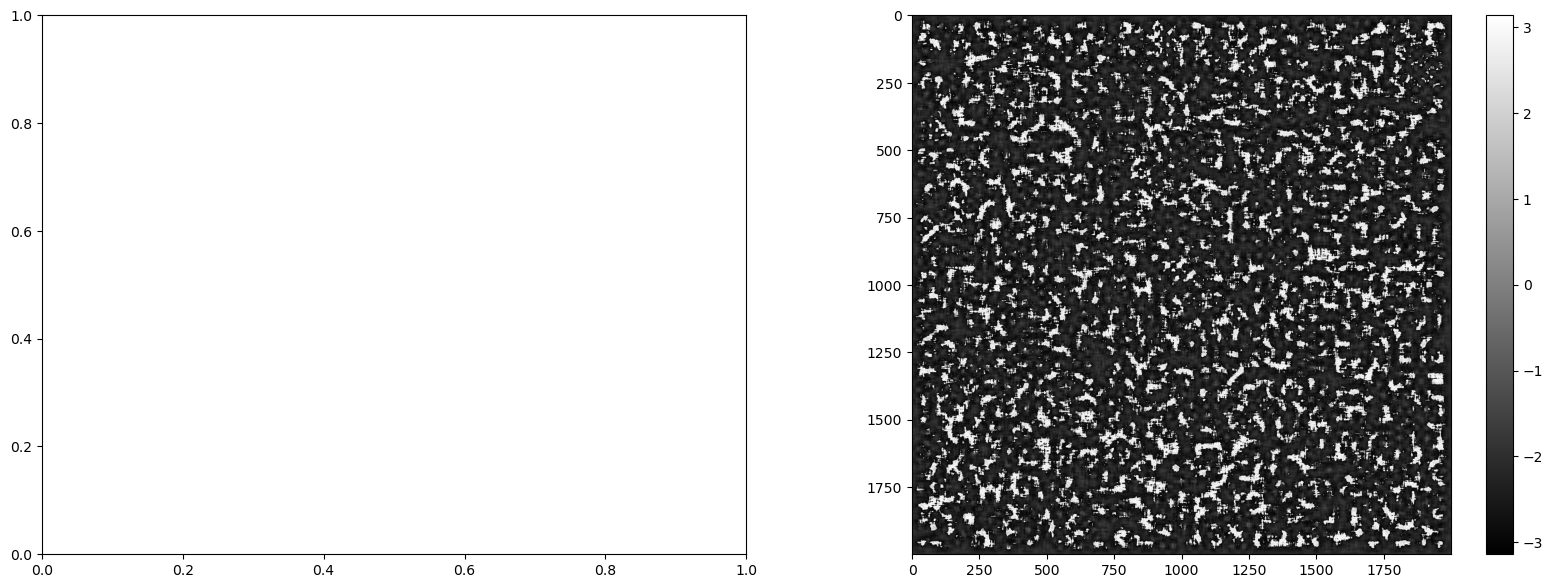

In [4]:
field = np.zeros([nx, nx])
field[:, :] = 80

phase_delay = np.exp(-1j*(2*np.pi/wl)*opd)
output_field_2 = propagator.propagate(field*phase_delay, wl/1.49, [dx, dx], 500e-6, padding=1024)
# *np.exp(-1j*(2*np.pi/wl)*50*50e-9)

fig, axs = plt.subplots(1, 2, figsize=(20, 7))

# cm0 = axs[0].imshow(np.abs(output_field)**2, cmap='gray')
# plt.colorbar(cm0, ax=axs[0])

cm1 = axs[1].imshow(np.abs(output_field_2)**2, cmap='gray')
plt.colorbar(cm1, ax=axs[1])

plt.show()

fig, axs = plt.subplots(1, 2, figsize=(20, 7))

# cm0 = axs[0].imshow(np.angle(output_field), cmap='gray')
# plt.colorbar(cm0, ax=axs[0])

cm1 = axs[1].imshow(np.angle(output_field_2), cmap='gray')
plt.colorbar(cm1, ax=axs[1])

plt.show()

# fig, axs = plt.subplots(1, 2, figsize=(20, 7))

# cm0 = axs[0].imshow(np.abs(output_field) - np.abs(output_field_2), cmap='gray', vmax=1e-3, vmin=-1e-3)
# plt.colorbar(cm0, ax=axs[0])

# cm1 = axs[1].imshow(np.angle(output_field) - np.angle(output_field_2), cmap='gray', vmax=1e-3, vmin=-1e-3)
# plt.colorbar(cm1, ax=axs[1])

# plt.show()

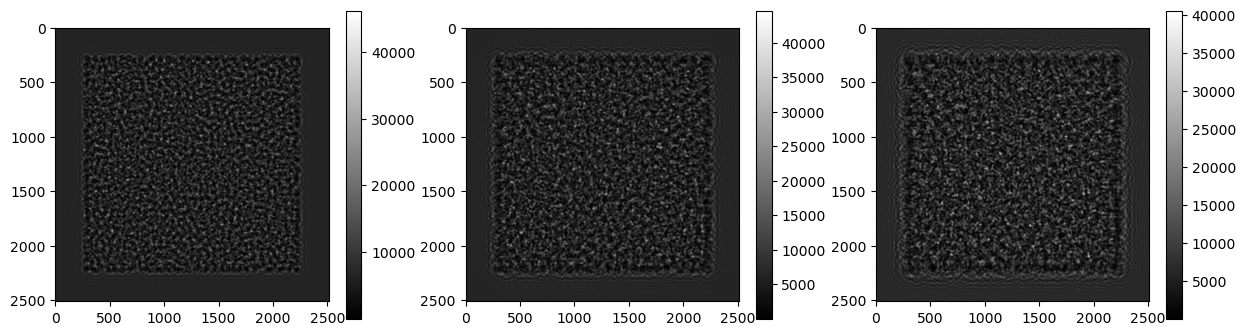

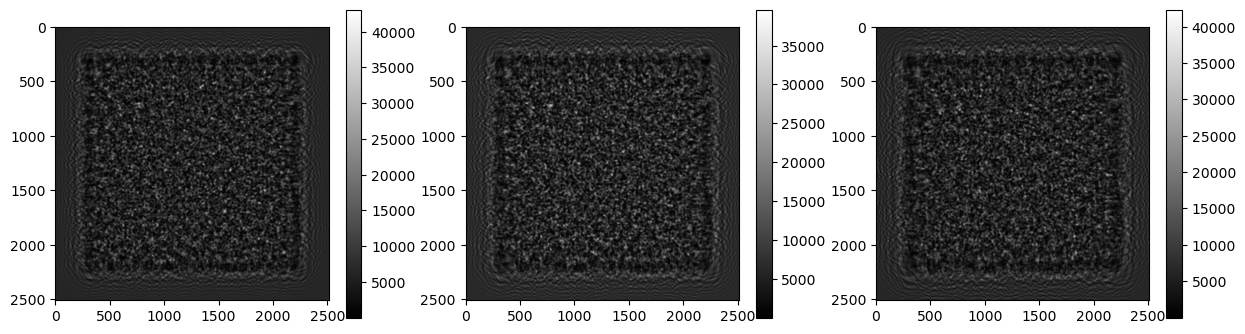

In [5]:
fig, axs = plt.subplots(1, 3, figsize=(15, 4))

field_z1 = propagator.propagate(np.pad(field*phase_delay, 256, 'edge'), 
                                            wl/1.49, [dx, dx], 1.e-3, padding=None)

field_z2 = propagator.propagate(np.pad(field*phase_delay, 256, 'edge'), 
                                            wl/1.49, [dx, dx], 2.e-3, padding=None)

field_z3 = propagator.propagate(np.pad(field*phase_delay, 256, 'edge'), 
                                            wl/1.49, [dx, dx], 3.e-3, padding=None)

cm0 = axs[0].imshow(np.abs(field_z1)**2, cmap='gray')
plt.colorbar(cm0, ax=axs[0])

cm1 = axs[1].imshow(np.abs(field_z2)**2, cmap='gray')
plt.colorbar(cm1, ax=axs[1])

cm2 = axs[2].imshow(np.abs(field_z3)**2, cmap='gray')
plt.colorbar(cm2, ax=axs[2])

plt.show()

fig, axs = plt.subplots(1, 3, figsize=(15, 4))

field_z4 = propagator.propagate(np.pad(field*phase_delay, 256, 'edge'), 
                                            wl/1.49, [dx, dx], 4.e-3, padding=None)

field_z5 = propagator.propagate(np.pad(field*phase_delay, 256, 'edge'), 
                                            wl/1.49, [dx, dx], 5.e-3, padding=None)

field_z6 = propagator.propagate(np.pad(field*phase_delay, 256, 'edge'), 
                                            wl/1.49, [dx, dx], 6.e-3, padding=None)

cm0 = axs[0].imshow(np.abs(field_z4)**2, cmap='gray')
plt.colorbar(cm0, ax=axs[0])

cm1 = axs[1].imshow(np.abs(field_z5)**2, cmap='gray')
plt.colorbar(cm1, ax=axs[1])

cm2 = axs[2].imshow(np.abs(field_z6)**2, cmap='gray')
plt.colorbar(cm2, ax=axs[2])

plt.show()

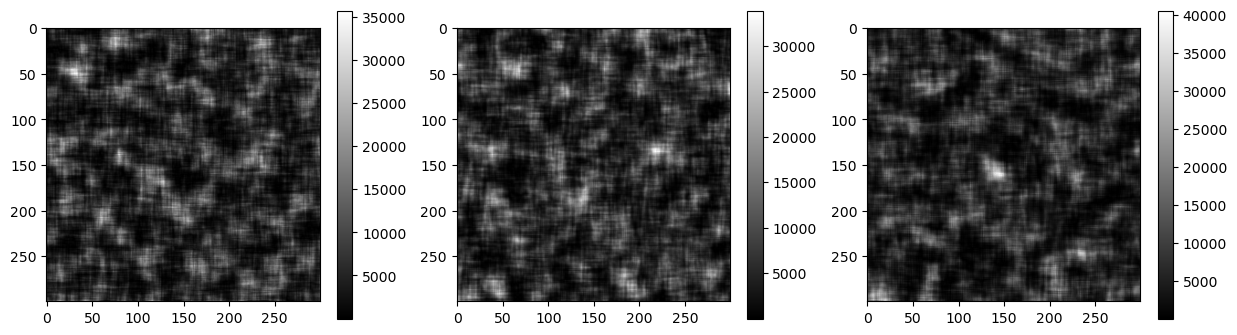

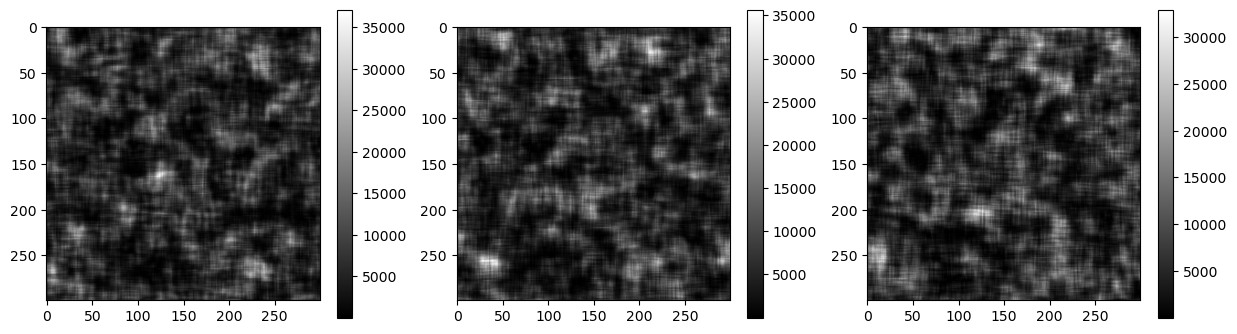

In [6]:
fig, axs = plt.subplots(1, 3, figsize=(15, 4))

z1_patch = field_z1[1000:1300, 1000:1300]
z2_patch = field_z2[1000:1300, 1000:1300]
z3_patch = field_z3[1000:1300, 1000:1300]

cm0 = axs[0].imshow(np.abs(z1_patch)**2, cmap='gray')
plt.colorbar(cm0, ax=axs[0])

cm1 = axs[1].imshow(np.abs(z2_patch)**2, cmap='gray')
plt.colorbar(cm1, ax=axs[1])

cm2 = axs[2].imshow(np.abs(z3_patch)**2, cmap='gray')
plt.colorbar(cm2, ax=axs[2])

plt.show()

fig, axs = plt.subplots(1, 3, figsize=(15, 4))

z4_patch = field_z4[1000:1300, 1000:1300]
z5_patch = field_z5[1000:1300, 1000:1300]
z6_patch = field_z6[1000:1300, 1000:1300]

cm0 = axs[0].imshow(np.abs(z4_patch)**2, cmap='gray')
plt.colorbar(cm0, ax=axs[0])

cm1 = axs[1].imshow(np.abs(z5_patch)**2, cmap='gray')
plt.colorbar(cm1, ax=axs[1])

cm2 = axs[2].imshow(np.abs(z6_patch)**2, cmap='gray')
plt.colorbar(cm2, ax=axs[2])

plt.show()

In [7]:
corr_z1 = correlate2d(np.abs(z1_patch)**2, np.abs(z1_patch)**2)
corr_z2 = correlate2d(np.abs(z2_patch)**2, np.abs(z2_patch)**2)
corr_z3 = correlate2d(np.abs(z3_patch)**2, np.abs(z3_patch)**2)
corr_z4 = correlate2d(np.abs(z4_patch)**2, np.abs(z4_patch)**2)
corr_z5 = correlate2d(np.abs(z5_patch)**2, np.abs(z5_patch)**2)
corr_z6 = correlate2d(np.abs(z6_patch)**2, np.abs(z6_patch)**2)

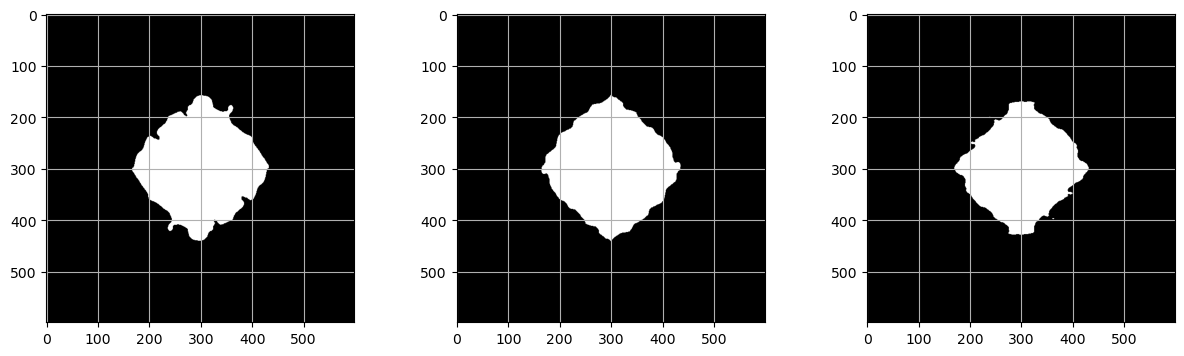

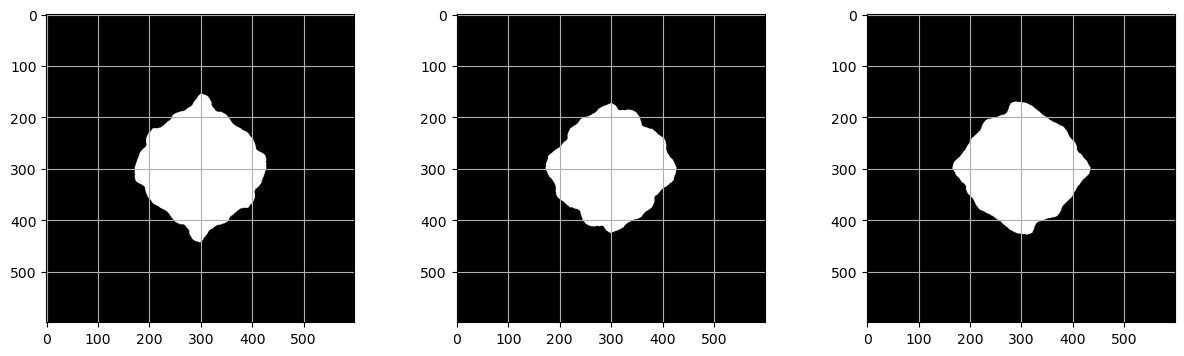

44583
45729
39433
44525
41215
42815


In [8]:
fig, axs = plt.subplots(1, 3, figsize=(15, 4))

cm0 = axs[0].imshow(corr_z1/corr_z1.max() > np.exp(-1), cmap='gray')
axs[0].grid()
# plt.colorbar(cm0, ax=axs[0])

cm1 = axs[1].imshow(corr_z2/corr_z2.max() > np.exp(-1), cmap='gray')
axs[1].grid()
# plt.colorbar(cm1, ax=axs[1])

cm2 = axs[2].imshow(corr_z3/corr_z3.max() > np.exp(-1), cmap='gray')
axs[2].grid()
# plt.colorbar(cm2, ax=axs[2])

plt.show()

fig, axs = plt.subplots(1, 3, figsize=(15, 4))

cm0 = axs[0].imshow(corr_z4/corr_z4.max() > np.exp(-1), cmap='gray')
axs[0].grid()
# plt.colorbar(cm0, ax=axs[0])

cm1 = axs[1].imshow(corr_z5/corr_z5.max() > np.exp(-1), cmap='gray')
axs[1].grid()
# plt.colorbar(cm1, ax=axs[1])

cm2 = axs[2].imshow(corr_z6/corr_z6.max() > np.exp(-1), cmap='gray')
axs[2].grid()
# plt.colorbar(cm2, ax=axs[2])

plt.show()

print(np.sum(corr_z1/corr_z1.max() > np.exp(-1)))
print(np.sum(corr_z2/corr_z2.max() > np.exp(-1)))
print(np.sum(corr_z3/corr_z3.max() > np.exp(-1)))
print(np.sum(corr_z4/corr_z4.max() > np.exp(-1)))
print(np.sum(corr_z5/corr_z5.max() > np.exp(-1)))
print(np.sum(corr_z6/corr_z6.max() > np.exp(-1)))

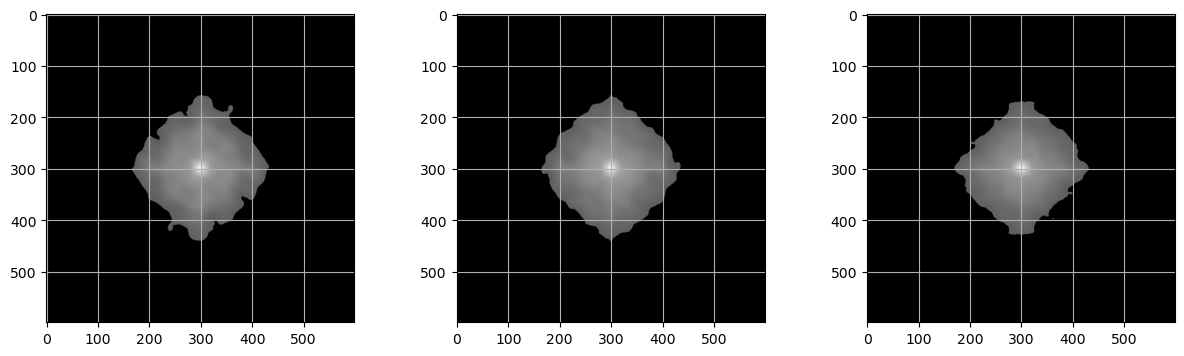

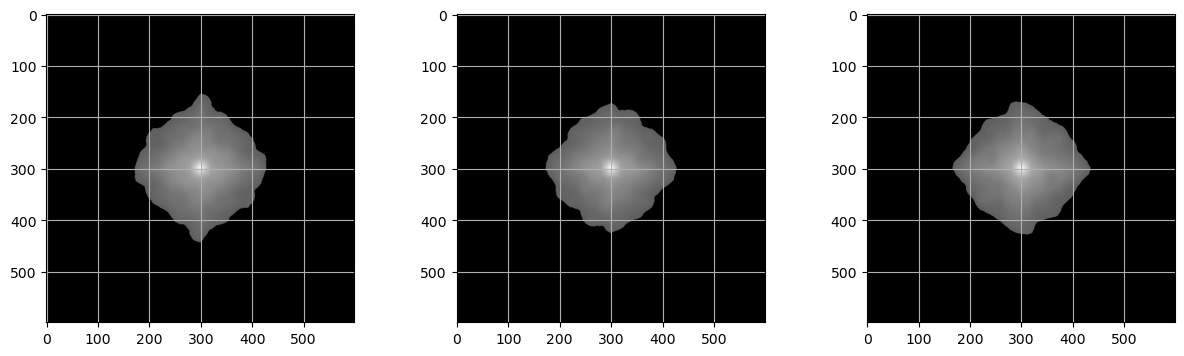

20669.884737307457
21274.476623087456
18099.951130750822
20690.103006239246
18951.36203817419
20031.648943928318


In [9]:
fig, axs = plt.subplots(1, 3, figsize=(15, 4))

cm0 = axs[0].imshow(np.where(corr_z1/corr_z1.max() > np.exp(-1), 
                             corr_z1/corr_z1.max(), 0), cmap='gray')
axs[0].grid()
# plt.colorbar(cm0, ax=axs[0])

cm1 = axs[1].imshow(np.where(corr_z2/corr_z2.max() > np.exp(-1), 
                             corr_z2/corr_z2.max(), 0), cmap='gray')
axs[1].grid()
# plt.colorbar(cm1, ax=axs[1])

cm2 = axs[2].imshow(np.where(corr_z3/corr_z3.max() > np.exp(-1), 
                             corr_z3/corr_z3.max(), 0), cmap='gray')
axs[2].grid()
# plt.colorbar(cm2, ax=axs[2])

plt.show()

fig, axs = plt.subplots(1, 3, figsize=(15, 4))

cm0 = axs[0].imshow(np.where(corr_z4/corr_z4.max() > np.exp(-1), 
                             corr_z4/corr_z4.max(), 0), cmap='gray')
axs[0].grid()
# plt.colorbar(cm0, ax=axs[0])

cm1 = axs[1].imshow(np.where(corr_z5/corr_z5.max() > np.exp(-1), 
                             corr_z5/corr_z5.max(), 0), cmap='gray')
axs[1].grid()
# plt.colorbar(cm1, ax=axs[1])

cm2 = axs[2].imshow(np.where(corr_z6/corr_z6.max() > np.exp(-1), 
                             corr_z6/corr_z6.max(), 0), cmap='gray')
axs[2].grid()
# plt.colorbar(cm2, ax=axs[2])

plt.show()

print(np.sum(np.where(corr_z1/corr_z1.max() > np.exp(-1), corr_z1/corr_z1.max(), 0)))
print(np.sum(np.where(corr_z2/corr_z2.max() > np.exp(-1), corr_z2/corr_z2.max(), 0)))
print(np.sum(np.where(corr_z3/corr_z3.max() > np.exp(-1), corr_z3/corr_z3.max(), 0)))
print(np.sum(np.where(corr_z4/corr_z4.max() > np.exp(-1), corr_z4/corr_z4.max(), 0)))
print(np.sum(np.where(corr_z5/corr_z5.max() > np.exp(-1), corr_z5/corr_z5.max(), 0)))
print(np.sum(np.where(corr_z6/corr_z6.max() > np.exp(-1), corr_z6/corr_z6.max(), 0)))

In [1]:
# cap = cv2.VideoCapture(0)

# # Define the codec and create VideoWriter object
# #fourcc = cv2.cv.CV_FOURCC(*'DIVX')
# #out = cv2.VideoWriter('output.avi',fourcc, 20.0, (640,480))
# out = cv2.VideoWriter('v9/v9_3/10um_250nm_2_mask_prop_abs.avi', cv2.VideoWriter_fourcc(*'XVID'), 20, (200, 200), isColor=False)

# for i in range(1, 3000, 10):
#     frame = propagator.propagate(field*phase_delay, wl/1.49, [dx, dx], i*1e-6, padding=256)
    
#     frame = np.abs(frame)**2
#     # frame = convolve2d(frame, np.ones([10, 10]), mode='valid')[::10, ::10]
#     frame = np.array(((frame - frame.min())/(frame.max() - frame.min()))*255, dtype=np.uint8)

#     # write the flipped frame
#     out.write(frame)

# # Release everything if job is finished
# out.release()

In [55]:
frame.shape, 2000*500e-9/1e-3

((200, 200), 1.0)

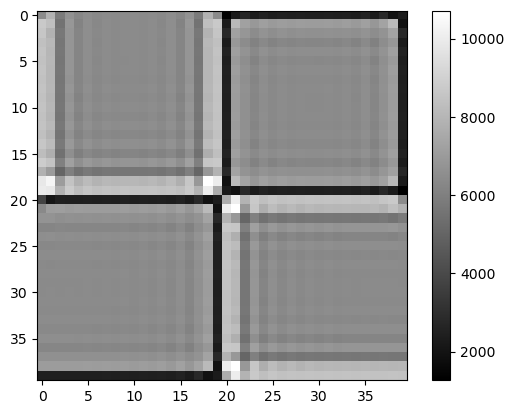

In [76]:
frame = propagator.propagate(field*phase_delay, wl/1.49, [dx, dx], 2e-6, padding=256)
frame = np.abs(frame)**2
plt.imshow(frame[200:240, 200:240], cmap='gray')
plt.colorbar()

670086.8818796156 670086.8818796158
670089.5544105641 670089.5544105642


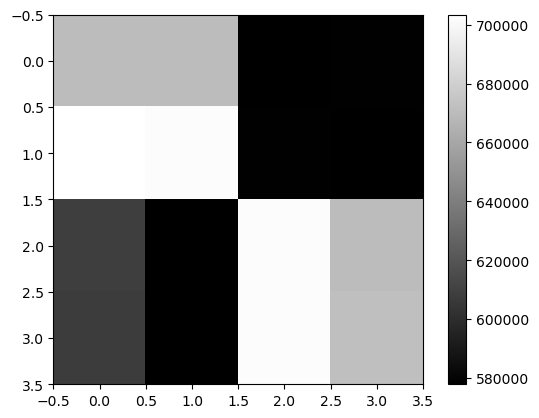

In [81]:
frame_sensor = convolve2d(frame, np.ones([10, 10]), mode='valid')[::10, ::10]
plt.imshow(frame_sensor[20:24, 20:24], cmap='gray')
plt.colorbar()
print(np.sum(frame[200:210, 200:210]), frame_sensor[20, 20])
print(np.sum(frame[200:210, 210:220]), frame_sensor[20, 21])

In [17]:
500e-9*2000/1e-3

1.0

In [ ]:
# fields = [field_z1, field_z2, field_z3, field_z4, field_z5, field_z6]

# for idx, field in enumerate(fields):
#     field = np.abs(field)**2
#     field_sensor = convolve2d(field, np.ones([10, 10]), mode='valid')[::10, ::10]
    
#     field = np.array(((field - field.min())/(field.max() - field.min()))*(2**16 - 1), dtype=np.uint16)
#     field_sensor = np.array(((field_sensor - field_sensor.min())/(field_sensor.max() - field_sensor.min()))*(2**16 - 1), dtype=np.uint16)    
    
#     tifffile.imwrite(f'v9/v9_3/10um_250nm_mask_prop_{idx}_mm_int_aereial.tiff', field)
#     tifffile.imwrite(f'v9/v9_3/10um_250nm_mask_prop_{idx}_mm_int_sensor.tiff', field_sensor)